# 01 - EDA: PDBbind v2020 refined + CASF-2016

Quick look at the dataset: split integrity, pK distribution, affinity types, year coverage, resolution.

**Prereq:** `python scripts/download_pdbbind.py` to populate `data/raw/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from plb.data.pdbbind import find_default_paths, load_casf2016_coreset_ids, load_refined_index
from plb.data.splits import make_splits

sns.set_theme(style="whitegrid", context="notebook")
DATA_ROOT = Path("../data")
paths = find_default_paths(DATA_ROOT)
paths

{'refined_root': WindowsPath('../data/raw/PDBbind_v2020_refined/refined-set'),
 'refined_index': WindowsPath('../data/raw/PDBbind_v2020_refined/refined-set/index/INDEX_refined_data.2020'),
 'casf_root': WindowsPath('../data/raw/CASF-2016'),
 'casf_coreset': WindowsPath('../data/raw/CASF-2016/power_scoring/CoreSet.dat')}

In [2]:
refined = load_refined_index(paths["refined_index"])
casf_ids = load_casf2016_coreset_ids(paths["casf_coreset"])
print(f"refined-set entries: {len(refined)}")
print(f"CASF-2016 core-set entries: {len(casf_ids)}")
refined.head()

refined-set entries: 5316
CASF-2016 core-set entries: 285


,pdb_id,resolution,release_year,pK,affinity_raw,ligand_name
0,10gs,2.2,1998,6.40,Ki=0.4uM,VWW
1,184l,1.8,1995,4.72,Kd=19uM,I4B
2,185l,1.8,1995,3.54,Kd=290uM,IND
3,186l,1.8,1995,4.85,Kd=14uM,N4B
4,187l,1.8,1995,3.37,Kd=422uM,PXY


In [3]:
split = make_splits(refined["pdb_id"].tolist(), casf_ids, val_frac=0.1, seed=42)
split.sizes

{'train': 4545, 'val': 505, 'test': 266}

### Sanity check: zero CASF-2016 leakage

In [4]:
casf_set = set(casf_ids)
leaked_train = casf_set & set(split.train)
leaked_val = casf_set & set(split.val)
print(f"CASF leaks into train: {len(leaked_train)}")
print(f"CASF leaks into val:   {len(leaked_val)}")
assert not leaked_train and not leaked_val, "CASF-2016 leakage detected"

CASF leaks into train: 0
CASF leaks into val:   0


## pK distribution

Train vs CASF-2016 test set — checking the test set is representative.

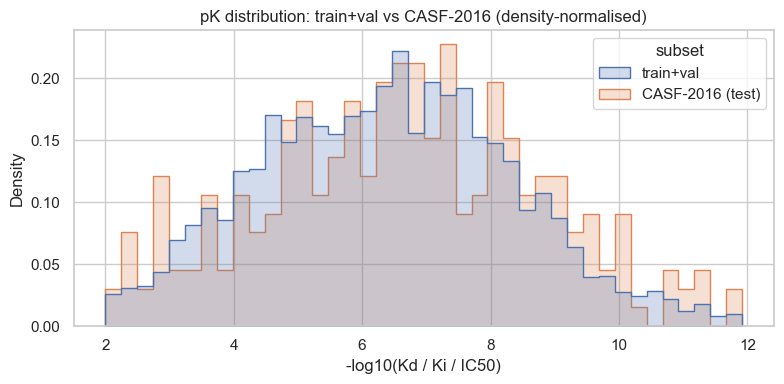

In [5]:
refined["subset"] = "train+val"
refined.loc[refined["pdb_id"].isin(casf_set), "subset"] = "CASF-2016 (test)"

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=refined,
    x="pK",
    hue="subset",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    ax=ax,
)
ax.set_title("pK distribution: train+val vs CASF-2016 (density-normalised)")
ax.set_xlabel("-log10(Kd / Ki / IC50)")
plt.tight_layout()

## Affinity-type breakdown

Kd / Ki / IC50 proportions (IC50 is noisier).

In [6]:
def affinity_kind(s: str) -> str:
    for k in ("Kd", "Ki", "IC50"):
        if s.startswith(k):
            return k
    return "other"


refined["affinity_kind"] = refined["affinity_raw"].map(affinity_kind)
refined.groupby(["subset", "affinity_kind"]).size().unstack(fill_value=0)

affinity_kind,Kd,Ki
subset,,
CASF-2016 (test),100,166
train+val,2683,2367


## Release year coverage

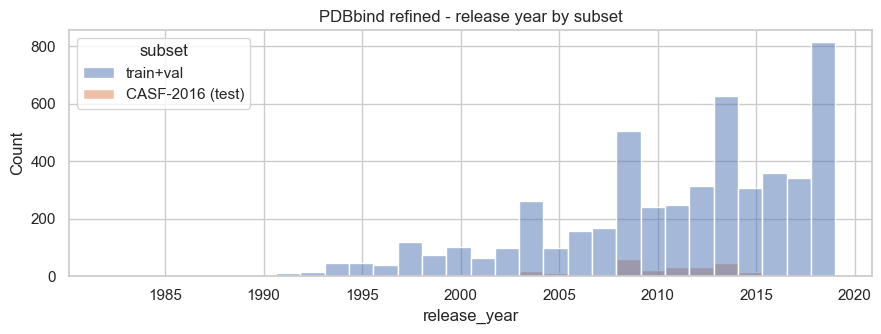

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(data=refined, x="release_year", hue="subset", bins=30, ax=ax)
ax.set_title("PDBbind refined - release year by subset")
plt.tight_layout()

## Resolution

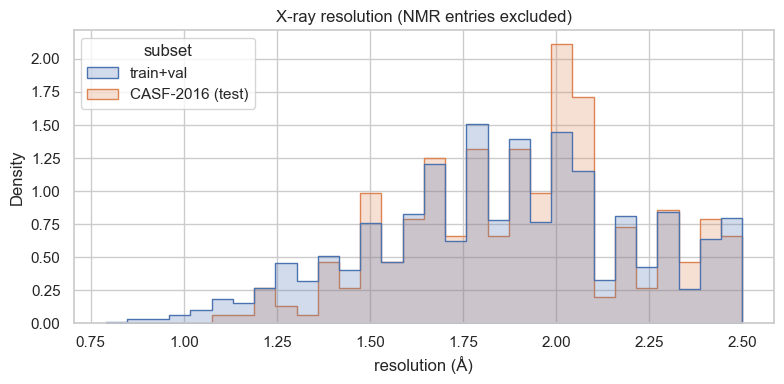

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=refined.dropna(subset=["resolution"]),
    x="resolution",
    hue="subset",
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    ax=ax,
)
ax.set_title("X-ray resolution (NMR entries excluded)")
ax.set_xlabel("resolution (Å)")
plt.tight_layout()

## Summary table

In [ ]:
summary = (
    refined.groupby("subset")
    .agg(
        n=("pdb_id", "count"),
        pK_mean=("pK", "mean"),
        pK_std=("pK", "std"),
        pK_min=("pK", "min"),
        pK_max=("pK", "max"),
        year_min=("release_year", "min"),
        year_max=("release_year", "max"),
    )
    .round(2)
)
summary

,n,pK_mean,pK_std,pK_min,pK_max,year_min,year_max
subset,,,,,,,
CASF-2016 (test),266,6.61,2.15,2.07,11.82,1989,2015
train+val,5050,6.38,1.94,2.00,11.92,1982,2019


: 